# 🚀 NetworkX Workshop
## Session 3
### 🌹 Special thanks to Mr. Yahya Hematyar Tabatabaei, whose insightful NetworkX workshop inspired and guided the creation of this notebook



This tutorial will cover:

- Subgraph
- K-Core and Hierarchical Models
- Network models
- Assortativity and Disassortativity in Networks
- Null Models in Network Analysis
- Network Percolation


## Import libraries

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import sys
import os
import warnings
import itertools
import math
import random

In [21]:
parent_dir = os.path.abspath(os.path.join(os.getcwd()))
sys.path.append(parent_dir)
warnings.simplefilter("ignore", category=FutureWarning)

# Sub-graph
* induced an non-induced

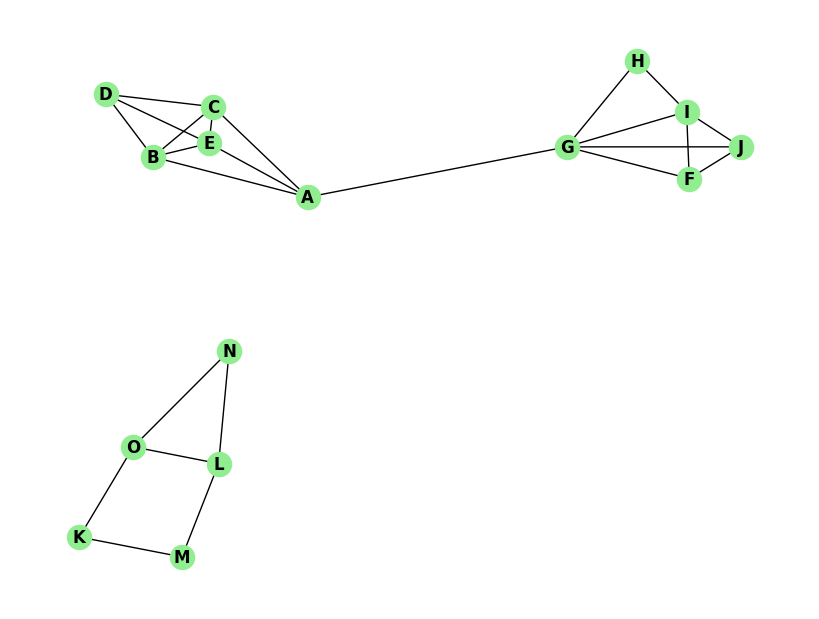

In [27]:
G = nx.Graph()

edges = [
    ('A', 'B'), ('A', 'C'), ('A', 'E'), ('A', 'G'), #and ('A', 'N')
    ('B', 'C'), ('B', 'E'), ('B', 'D'),
    ('C', 'D'), ('C', 'E'),
    ('D', 'E'),
    ('G', 'F'), ('G', 'H'), ('G', 'I'), ('G', 'J'),
    ('F', 'J'), ('F', 'I'), ('I', 'J'), ('I', 'H'),
    ('N', 'L'), ('N', 'O'),
    ('M', 'L'), ('M', 'K'), ('O', 'K'), ('O', 'L')
]

G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
full_G = nx.Graph()
full_edges = [
    ('A', 'B'), ('A', 'C'), ('A', 'E'), ('A', 'G'), ('A', 'N'),
    ('B', 'C'), ('B', 'E'), ('B', 'D'),
    ('C', 'D'), ('C', 'E'),
    ('D', 'E'),
    ('G', 'F'), ('G', 'H'), ('G', 'I'), ('G', 'J'),
    ('F', 'J'), ('F', 'I'), ('I', 'J'), ('I', 'H'),
    ('N', 'L'), ('N', 'O'),
    ('M', 'L'), ('M', 'K'), ('O', 'K'), ('O', 'L')
]
full_G.add_edges_from(full_edges)

pos = nx.spring_layout(full_G, seed=50)

nx.draw(G, pos, with_labels=True, node_color='lightgreen', font_weight='bold', font_size=12, edge_color='black')
plt.savefig('component_modified.png')
plt.show()

In [28]:
nx.number_connected_components(G)


2

In [29]:
sorted(nx.connected_components(G))


[{'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'}, {'K', 'L', 'M', 'N', 'O'}]

In [30]:
nx.node_connected_component(G,'M')

{'K', 'L', 'M', 'N', 'O'}

### Giant Component

In [31]:
components = list(nx.connected_components(G))

giant_cc_nodes = max(components, key=len)
G_giant = G.subgraph(giant_cc_nodes).copy()
print(f"Giant component has {G_giant.number_of_nodes()} nodes ({len(giant_cc_nodes) / G.number_of_nodes():.1%} of the graph)")


Giant component has 10 nodes (66.7% of the graph)


## clique
A clique is a set of nodes all mutually connected. It’s the graph-theory analogue of ‘everyone knows everyone else.

In [37]:
G = nx.karate_club_graph()
G = nx.convert_node_labels_to_integers(G,first_label=1)
cliques = list(nx.find_cliques(G))
print(cliques)
sizes = [len(c) for c in cliques]
max_size = max(sizes)

print(f"Total maximal cliques: {len(cliques)}")
print(f"Largest clique size: {max_size}")
largest = [c for c in cliques if len(c)==max_size]
print("Largest cliques:", largest)


[[1, 32], [1, 2, 18], [1, 2, 3, 4, 8], [1, 2, 3, 4, 14], [1, 2, 20], [1, 2, 22], [1, 5, 11], [1, 5, 7], [1, 6, 11], [1, 6, 7], [1, 9, 3], [1, 12], [1, 13, 4], [2, 31], [3, 33, 9], [3, 10], [3, 28], [3, 29], [6, 17, 7], [34, 33, 32], [34, 33, 9, 31], [34, 33, 15], [34, 33, 16], [34, 33, 19], [34, 33, 21], [34, 33, 23], [34, 33, 24, 30], [34, 10], [34, 14], [34, 20], [34, 27, 30], [34, 28, 24], [34, 29, 32], [25, 32, 26], [25, 28], [26, 24]]
Total maximal cliques: 36
Largest clique size: 5
Largest cliques: [[1, 2, 3, 4, 8], [1, 2, 3, 4, 14]]


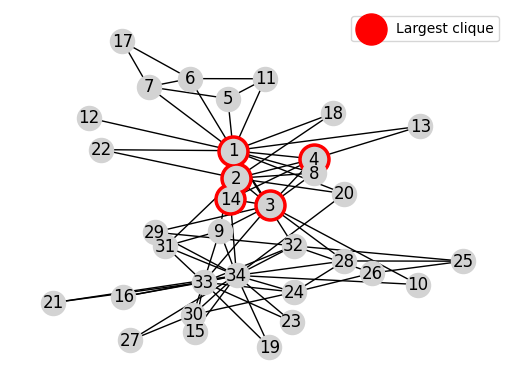

In [42]:
pos = nx.spring_layout(G)

clique = largest[1]
nx.draw_networkx_nodes(G, pos,
                       nodelist=clique,
                       node_color='red',node_size=500,
                       label="Largest clique")
nx.draw(G, pos, node_color='lightgray', with_labels=True)

plt.legend(scatterpoints=1)
plt.show()


# 📌 Hierarchical Structure in Networks

Many real-world networks exhibit **hierarchical organization**:

- High-degree nodes tend to be **less clustered**, acting as **hubs** or **bridges**
- Low-degree nodes cluster around them in **nested shells**
- These patterns reflect the **core–periphery structure** of complex networks

---

## 🧩 What is a K-Core?

A **k-core** of a graph is a **maximal subgraph** in which each node has **degree ≥ k** (within that subgraph).

- It is computed by **recursively removing all nodes** with degree less than $ k $
- The process yields a **nested sequence** of subgraphs:

$$
\text{0-core} \supseteq \text{1-core} \supseteq \text{2-core} \supseteq \dots
$$

- Nodes in higher cores are **more centrally embedded** and structurally important

---

## 🌀 Shell Index (Core Number)

Each node is assigned a **shell index** (or **core number**):

- It is the **highest value of $ k $** such that the node belongs to the $ k $ -core
- Reflects how **deeply embedded** a node is in the network
- **High shell index** → core of the network  
  **Low shell index** → periphery

---

## 📚 Why Is K-Core Decomposition Useful?

- Reveals the **hierarchical layers** of a network
- Helps distinguish **core vs peripheral** nodes
- Useful in:
  - **Social networks**: identifying influential users
  - **Biological networks**: discovering essential proteins
  - **Spreading dynamics**: modeling how influence or infection propagates
  - **Visualization**: simplifying complex structures by removing outer layers

---


In [43]:
G = nx.karate_club_graph()
core_numbers = nx.core_number(G)

for node, core in core_numbers.items():
    print(f"Node {node}: Shell index = {core}")


Node 0: Shell index = 4
Node 1: Shell index = 4
Node 2: Shell index = 4
Node 3: Shell index = 4
Node 4: Shell index = 3
Node 5: Shell index = 3
Node 6: Shell index = 3
Node 7: Shell index = 4
Node 8: Shell index = 4
Node 9: Shell index = 2
Node 10: Shell index = 3
Node 11: Shell index = 1
Node 12: Shell index = 2
Node 13: Shell index = 4
Node 14: Shell index = 2
Node 15: Shell index = 2
Node 16: Shell index = 2
Node 17: Shell index = 2
Node 18: Shell index = 2
Node 19: Shell index = 3
Node 20: Shell index = 2
Node 21: Shell index = 2
Node 22: Shell index = 2
Node 23: Shell index = 3
Node 24: Shell index = 3
Node 25: Shell index = 3
Node 26: Shell index = 2
Node 27: Shell index = 3
Node 28: Shell index = 3
Node 29: Shell index = 3
Node 30: Shell index = 4
Node 31: Shell index = 3
Node 32: Shell index = 4
Node 33: Shell index = 4


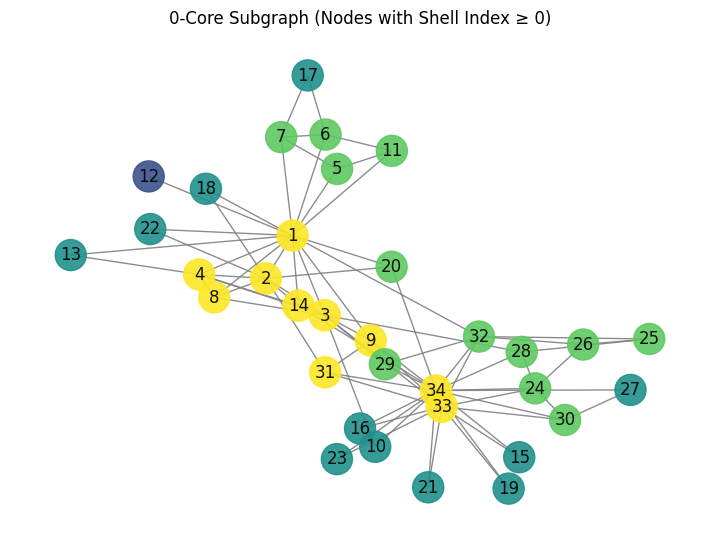

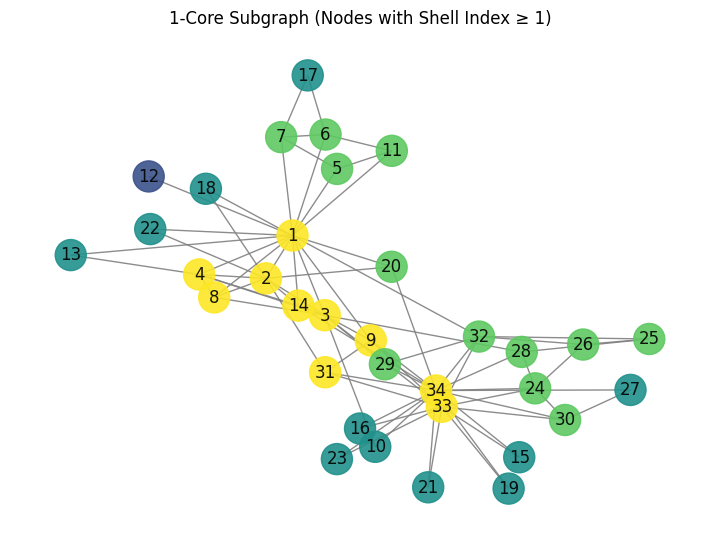

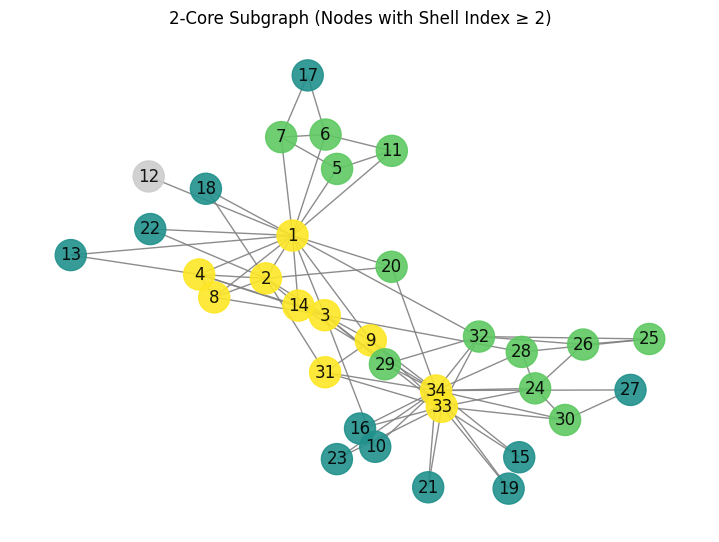

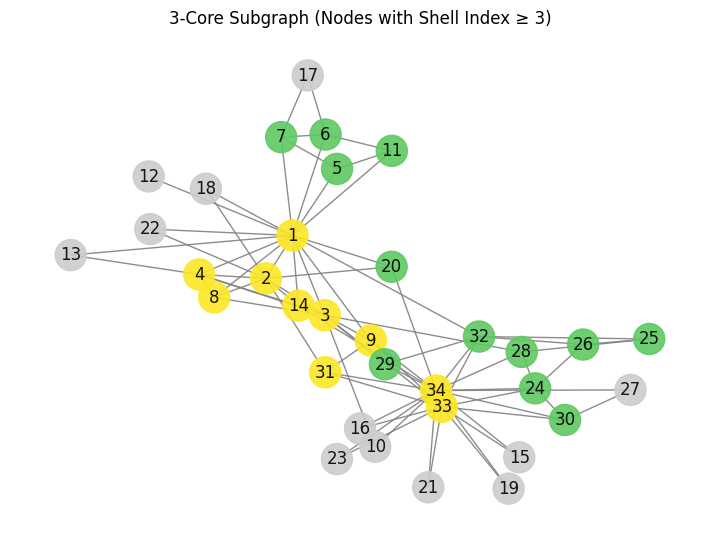

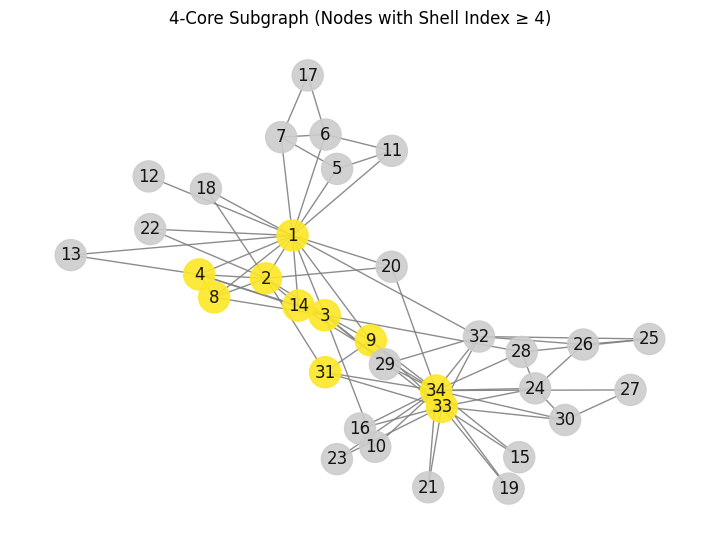

In [44]:
import matplotlib.colors as mcolors

G = nx.karate_club_graph()
G = nx.convert_node_labels_to_integers(G,first_label=1)
pos = nx.spring_layout(G, seed=42)

core_nums = nx.core_number(G)
max_core = max(core_nums.values())

cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=0, vmax=max_core)

for k in range(max_core + 1):
    node_colors = []
    for node in G.nodes():
        if core_nums[node] >= k:
            node_colors.append(cmap(norm(core_nums[node])))
        else:
            node_colors.append((0.8, 0.8, 0.8, 0.25))  

    plt.figure(figsize=(7, 5))
    nx.draw(
        G, pos, with_labels=True,
        node_color=node_colors,
        edge_color='gray',       
        node_size=500,
        alpha=0.9                
    )
    plt.title(f"{k}-Core Subgraph (Nodes with Shell Index ≥ {k})")
    plt.axis('off')
    plt.show()

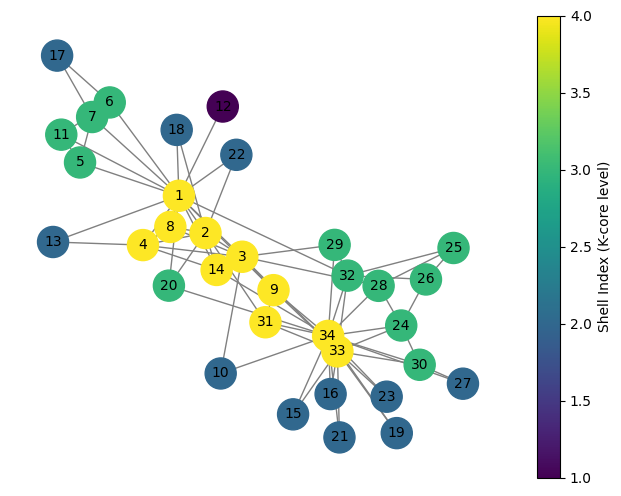

In [48]:
G = nx.karate_club_graph()
G = nx.convert_node_labels_to_integers(G,first_label=1)
pos = nx.spring_layout(G)

core_nums = nx.core_number(G)
max_core = max(core_nums.values())

node_colors = [core_nums[n] for n in G.nodes]

plt.figure(figsize=(8, 6))
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=500)
edges = nx.draw_networkx_edges(G, pos, edge_color='gray')
labels = nx.draw_networkx_labels(G, pos, font_size=10)

plt.colorbar(nodes, label='Shell Index (K-core level)')
plt.axis('off')
plt.show()


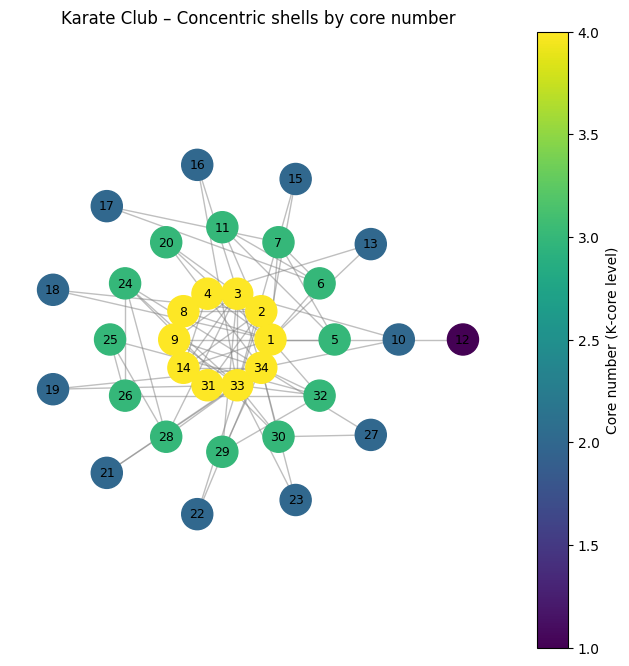

In [51]:
shells_by_core = {}
for node, core in core_nums.items():
    shells_by_core.setdefault(core, []).append(node)

sorted_cores = sorted(shells_by_core.keys())         
shells = [shells_by_core[core] for core in sorted_cores]  

radi = np.linspace(1.0, 0.2, len(shells))  

def custom_concentric_layout(shells, radii):
    pos = {}
    for shell_nodes, r in zip(shells, radii):
        n = len(shell_nodes)
        angles = np.linspace(0, 2*np.pi, n, endpoint=False)
        for node, theta in zip(shell_nodes, angles):
            pos[node] = (r * np.cos(theta), r * np.sin(theta))
    return pos

pos = custom_concentric_layout(shells, radi)

node_colors = [core_nums[n] for n in G.nodes]

plt.figure(figsize=(8, 8))
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                               cmap=plt.cm.viridis, node_size=500)
edges = nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
labels = nx.draw_networkx_labels(G, pos, font_size=9)
plt.colorbar(nodes, label='Core number (K‑core level)')
plt.axis('equal')   
plt.axis('off')
plt.title("Karate Club – Concentric shells by core number")
plt.show()

# Network models


<h3>
    <span style="color:#00FF00">G</span>
    <span style="color:#FF7F00">o</span>
    <span style="color:#FFFF00">o</span>
    <span style="color:#FF0000">g</span>
    <span style="color:#0000FF">l</span>
    <span style="color:#8B00FF">e</span> it: NetworkX Graph Generators
</h3>

[https://networkx.org/documentation/stable/reference/generators.html](https://networkx.org/documentation/stable/reference/generators.html)


In [10]:
def network_metrics(G):
    avg_clustering = nx.average_clustering(G)
    try:
        avg_shortest_path = nx.average_shortest_path_length(G)
    except nx.NetworkXError:
        avg_shortest_path = np.inf 
    return avg_clustering, avg_shortest_path

def avg_degree(G):
    return 2 * G.number_of_edges() / G.number_of_nodes()

def draw_network(L, title,    pos =None):
    plt.figure(figsize=(6, 6))
    nx.draw(L, pos, with_labels=False, node_color='lightblue', node_size=50, edge_color='gray')
    plt.title(title)
    plt.show()


### Network Examples


## 1. **Random Network (Erdős-Rényi Model)**
The Erdős-Rényi random graph is generated by connecting nodes randomly. Each pair of nodes is connected with a probability `p`.

**Parameters:**
- `n`: Number of nodes.
- `p`: Probability for edge creation.

**Use Case:**
- Useful for modeling random processes such as rumor spreading or social network formation where there’s no bias in connecting nodes.


**desired Average degree:**

$$
<k> = p (N-1)
$$


Erdős–Rényi Graph (n=100, p=0.1)
Average clustering coefficient: 0.0913
Average shortest path length: 2.2674747474747474
Average degree: 9.5600


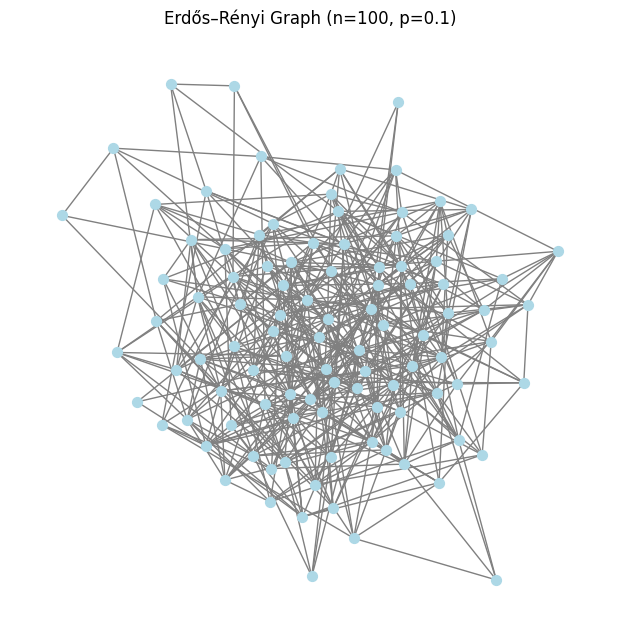

In [56]:
n = 100   
p = 0.1   
G_er = nx.erdos_renyi_graph(n, p)

clustering, avg_path = network_metrics(G_er)
avg_deg = avg_degree(G_er)

print( f"Erdős–Rényi Graph (n={n}, p={p})")
print(f"Average clustering coefficient: {clustering:.4f}")
print(f"Average shortest path length: {avg_path if avg_path != np.inf else 'disconnected (∞)'}")
print(f"Average degree: {avg_deg:.4f}")

draw_network(G_er, f"Erdős–Rényi Graph (n={n}, p={p})")

## 2. **Small-World Network (Watts-Strogatz Model)**
This network starts as a ring lattice and rewires some edges randomly. It retains the local clustering of lattice graphs and has the short average path lengths of random graphs.

**Parameters:**
- `n`: Number of nodes.
- `k`: Each node is joined with its `k` nearest neighbors in a ring topology.
- `p`: Probability of rewiring each edge.

**Use Case:**
- Used to model social networks and neural networks, where there’s high clustering and short path lengths between any two nodes.

**desired Average degree:**

$$
<k> = <k>
$$

Watts–Strogatz Graph (n=10, k=10, p=0)
Average clustering coefficient: 1.0000
Average shortest path length: 1.0
Average degree: 9.0000


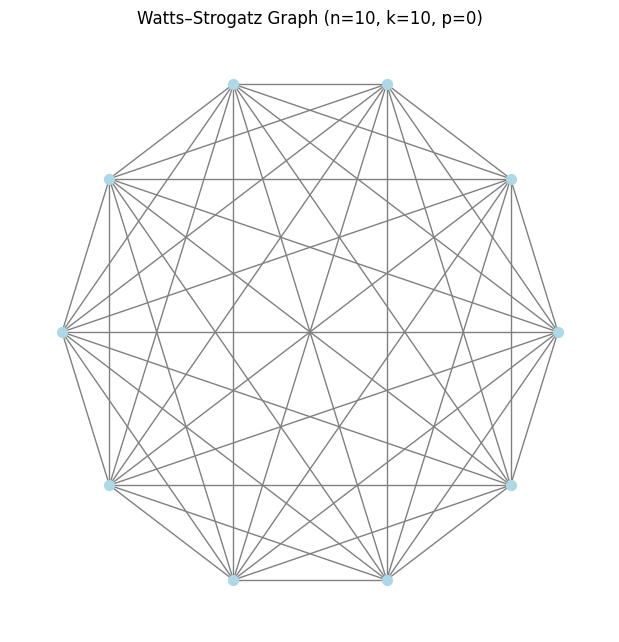

In [96]:
n = 10
k = 10
p = 0
G_ws = nx.watts_strogatz_graph(n, k, p, seed=42)

clustering, avg_path = network_metrics(G_ws)
avg_deg = avg_degree(G_ws)

print(f"Watts–Strogatz Graph (n={n}, k={k}, p={p})")
print(f"Average clustering coefficient: {clustering:.4f}")
print(f"Average shortest path length: {avg_path if avg_path != np.inf else 'disconnected (∞)'}")
print(f"Average degree: {avg_deg:.4f}")

draw_network(G_ws,  f"Watts–Strogatz Graph (n={n}, k={k}, p={p})",pos=nx.circular_layout(G_ws))


## 3. **Barabási-Albert Network (Scale-Free Network)**
This is a scale-free network where nodes are added one at a time, and each new node is connected to existing nodes with a probability that is proportional to the number of links that the existing nodes already have.

**Parameters:**
- `n`: Number of nodes.
- `m`: Number of edges to attach from a new node to existing nodes.

**Use Case:**
- Used to model networks like the Internet or citation networks, where some nodes (hubs) have a much higher degree than others.


**desired Average degree:**

$$
<k> \approx 2m
$$

Barabási–Albert Graph (n=100, m=3)
Average clustering coefficient: 0.1870
Average shortest path length: 2.515151515151515
Average degree: 5.8200


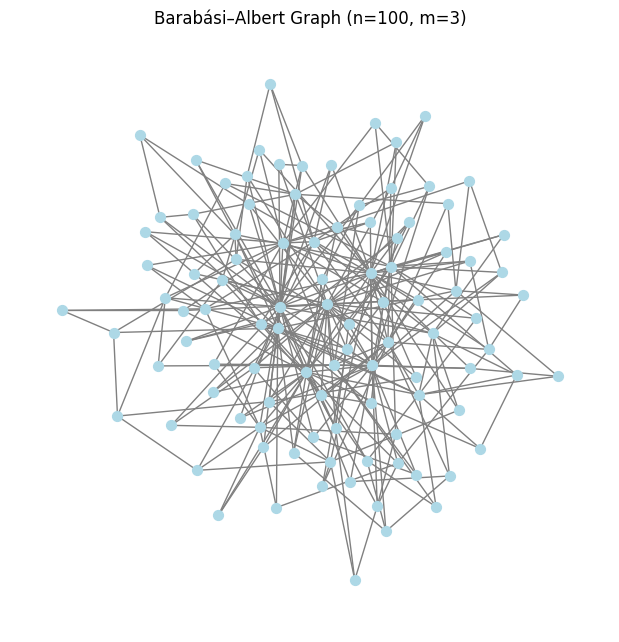

In [70]:
n = 100
m = 3     
G_ba = nx.barabasi_albert_graph(n, m, seed=42)

clustering, avg_path = network_metrics(G_ba)
avg_deg = avg_degree(G_ba)

print(f"Barabási–Albert Graph (n={n}, m={m})")
print(f"Average clustering coefficient: {clustering:.4f}")
print(f"Average shortest path length: {avg_path if avg_path != np.inf else 'disconnected (∞)'}")
print(f"Average degree: {avg_deg:.4f}")

draw_network(G_ba, f"Barabási–Albert Graph (n={n}, m={m})")

## 4. **Random Regular Network**
A random regular graph is a graph where each node has the same number of neighbors (`degree`), and the neighbors are chosen randomly.

**Parameters:**
- `n`: Number of nodes.
- `d`: Degree of each node (the number of neighbors).

**Use Case:**
- Useful for modeling systems with uniform interaction degrees, such as some physical and biological systems.
 
**desired Average degree:**

$$
<k> \, =\, <k>
$$

Random Regular Graph (n=100, d=4)
Average clustering coefficient: 0.0200
Average shortest path length: 3.5646464646464646
Average degree: 4.0000


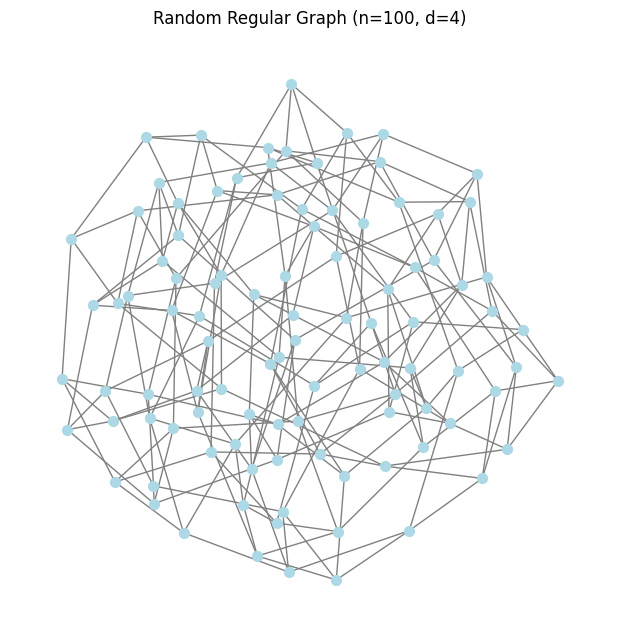

In [78]:
n = 100
d = 4    
G_rr = nx.random_regular_graph(d, n)

clustering, avg_path = network_metrics(G_rr)
avg_deg = avg_degree(G_rr)  

print(f"Random Regular Graph (n={n}, d={d})")
print(f"Average clustering coefficient: {clustering:.4f}")
print(f"Average shortest path length: {avg_path if avg_path != np.inf else 'disconnected (∞)'}")
print(f"Average degree: {avg_deg:.4f}")

draw_network(G_rr, f"Random Regular Graph (n={n}, d={d})",pos=nx.spring_layout(G_rr,seed=4))


## 5. **Grid Network**
A regular grid network has nodes arranged in a grid (usually 2D or 3D). Each node is connected to its nearest neighbors.

**Parameters:**
- `m`: Number of rows.
- `n`: Number of columns.

**Use Case:**
- Common in physical systems modeling, such as fluid dynamics or cellular automata.

 
**desired Average degree:**

$$
<k> \approx 2 \times Dimension
$$

![grid Network](grid.png)

 Average Clustering = 0.0000,  Average Shortest Path = 2.0000



## Assortativity and Disassortativity in Networks

**Assortativity** in a network refers to the tendency of nodes to connect to other nodes that are similar to themselves based on some attribute (e.g., degree, clustering coefficient, centrality, etc.).

In contrast, **disassortativity** occurs when nodes tend to connect to others that are different from themselves.

---

###  Mathematical Definition

Assortativity is often quantified using the **Pearson correlation coefficient** between the values of a given node attribute (e.g., degree) and the average of the same attribute across its neighbors.

- If the correlation is **positive**, the network is **assortative** with respect to that attribute.
- If the correlation is **negative**, the network is **disassortative**.
- A correlation near **zero** implies no particular preference (neutral mixing).

---


###  Why It Matters

Understanding assortativity helps reveal:
- **Robustness** and **vulnerability** in networks
- The **spread of information or disease**
- The **structure of social or technological systems**

Social networks tend to be assortative, while biological and technological networks often show disassortativity.


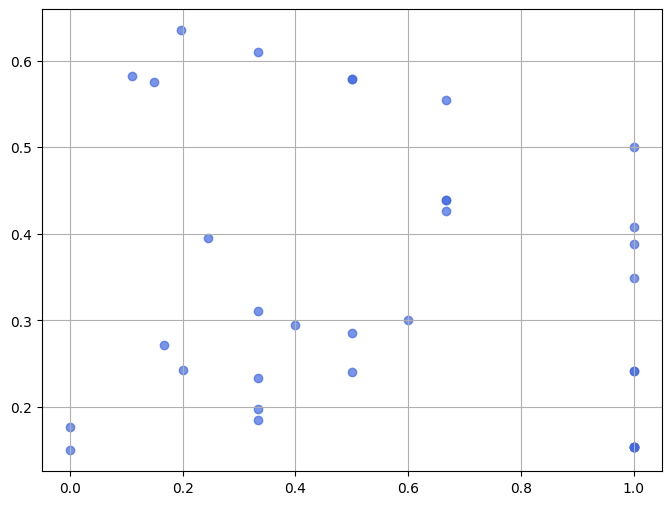

Pearson correlation: r = -0.2000
-0.47561309768461413


In [83]:
G = nx.karate_club_graph()
G = nx.convert_node_labels_to_integers(G,first_label=1)

deg = nx.clustering(G)

avg_neighbor_deg = {}
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if neighbors:
        avg = np.mean([deg[n] for n in neighbors])
    else:
        avg = np.nan
    avg_neighbor_deg[node] = avg

nodes = list(G.nodes())
x_vals = np.array([deg[n] for n in nodes])
y_vals = np.array([avg_neighbor_deg[n] for n in nodes])


plt.figure(figsize=(8, 6))
plt.scatter(x_vals, y_vals, color='royalblue', alpha=0.7)
plt.grid(True)
plt.show()

x_mean = np.mean(x_vals)
y_mean = np.mean(y_vals)
numerator = np.sum((x_vals - x_mean) * (y_vals - y_mean))
denominator = np.sqrt(np.sum((x_vals - x_mean)**2)) * np.sqrt(np.sum((y_vals - y_mean)**2))
r = numerator / denominator

print(f"Pearson correlation: r = {r:.4f}")
print(nx.degree_assortativity_coefficient(G))

### Compensatory

why these
$$ $$

print(f"Pearson correlation: r = {r:.4f}") 

print(nx.degree_assortativity_coefficient(G))
$$ $$

give different values?

Edge-based Pearson correlation: -0.4756
NetworkX assortativity: -0.4756


# 🎲 Null Models in Network Analysis

## 📌 What is a Null Model?

A **null model** is a randomized version of a network that preserves certain structural properties, typically:
- The **degree sequence**
- The **number of nodes and edges**

It helps answer the question:
> “Are the communities we observe **real** or just a result of random fluctuations?”

---

## 🔧 Common Null Models

### 🔹 Erdős–Rényi (ER) Model
- Randomly places edges with uniform probability
- Preserves node count and expected edge count
- Doesn’t preserve degree distribution

### 🔹 Configuration Model
- Randomizes edges while **preserving the degree sequence**


## 🧠 Why Use Null Models?

- Separate **true structure** from **randomness (noise)** 

---

   nodes = 34, edges = 78
   avg degree = 4.59
   clustering = 0.5706, avg shortest path = 2.4082


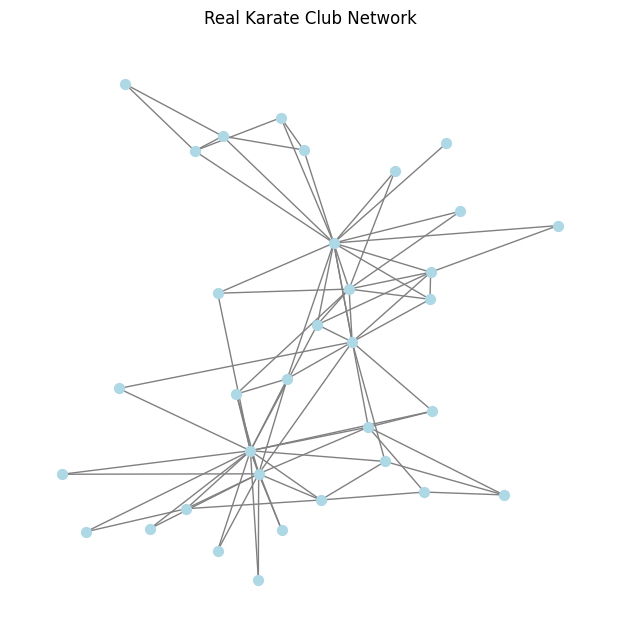


🎲 NULL MODEL 1: Erdős–Rényi (n=34, p=0.1390)
   (preserves node count & expected edges, destroys degree distribution)
   edges = 80 (expected ~78)
   avg degree = 4.71
   clustering = 0.2196, avg shortest path = inf


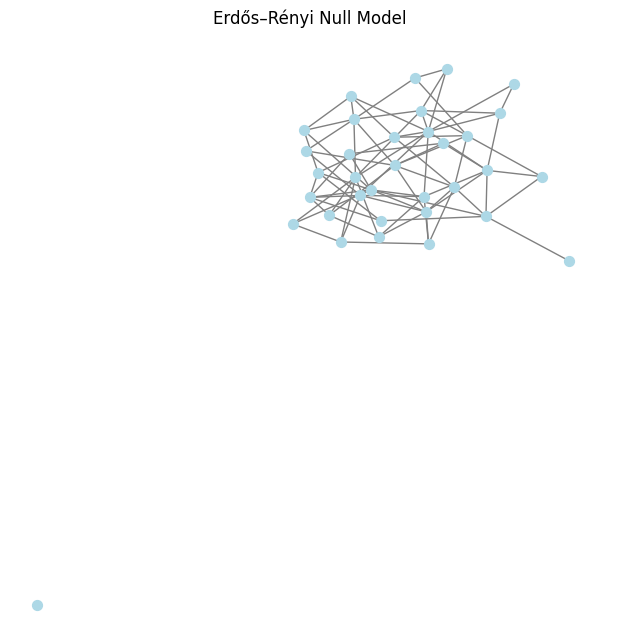


Multigraph has 78 edge stubs, 4 self-loops, 7 parallel connections.
Simple graph now has 67 edges (original real graph had 78)
(Degree sequence is no longer exactly preserved after this cleaning, but it is close in practice.)

clustering=0.1782, avg shortest path=2.4991


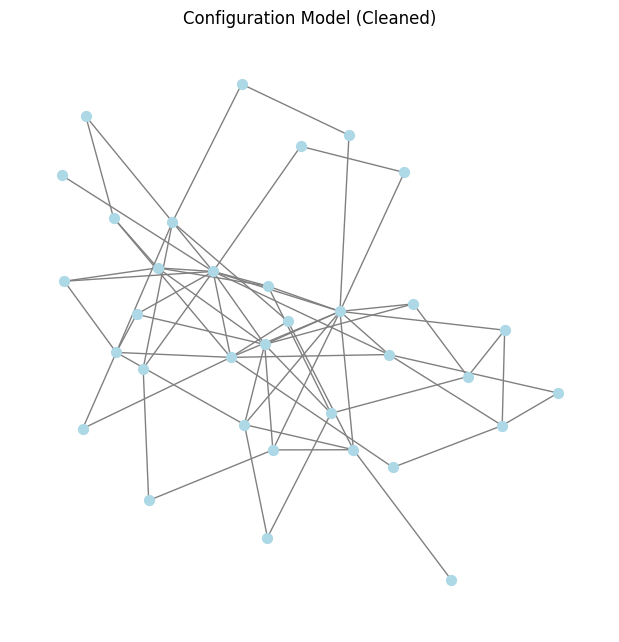


🔧 NULL MODEL 2: Configuration Model (degree‑preserving)
   (preserves exact degree sequence, no. of nodes, and edges)
   edges = 78 (should = 78)
   avg degree = 4.59
   clustering = 0.3548, avg shortest path = 2.2299


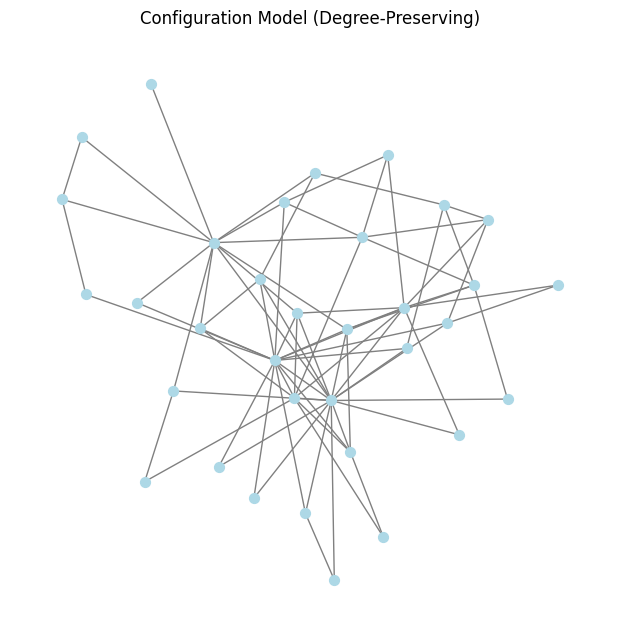


📈 COMPARISON OF METRICS
Network                        Clustering   Avg Path Avg Degree
------------------------------------------------------------
Real (Karate Club)                 0.5706     2.4082       4.59
Erdős–Rényi null                   0.2196        inf       4.71
Configuration null                 0.3548     2.2299       4.59
------------------------------------------------------------


In [85]:

G_real = nx.karate_club_graph()

n = G_real.number_of_nodes()
m = G_real.number_of_edges()
print(f"   nodes = {n}, edges = {m}")
print(f"   avg degree = {avg_degree(G_real):.2f}")

clust_real, path_real = network_metrics(G_real)
print(f"   clustering = {clust_real:.4f}, avg shortest path = {path_real:.4f}")

draw_network(G_real, "Real Karate Club Network")


p = 2 * m / (n * (n - 1))   
G_er = nx.erdos_renyi_graph(n, p)

print("\n" + "="*60)
print(f"🎲 NULL MODEL 1: Erdős–Rényi (n={n}, p={p:.4f})")
print(f"   (preserves node count & expected edges, destroys degree distribution)")

clust_er, path_er = network_metrics(G_er)
print(f"   edges = {G_er.number_of_edges()} (expected ~{m})")
print(f"   avg degree = {avg_degree(G_er):.2f}")
print(f"   clustering = {clust_er:.4f}, avg shortest path = {path_er:.4f}")

draw_network(G_er, "Erdős–Rényi Null Model")


degree_sequence = [d for _, d in G_real.degree()]


G_conf_multigraph = nx.configuration_model(degree_sequence)

loops_before = nx.number_of_selfloops(G_conf_multigraph)
multi_edges_before = G_conf_multigraph.number_of_edges() - len(set(G_conf_multigraph.edges()))
print("\n" + "="*60)

print(f"Multigraph has {G_conf_multigraph.number_of_edges()} edge stubs, "
      f"{loops_before} self-loops, {multi_edges_before} parallel connections.")

G_conf_simple = nx.Graph(G_conf_multigraph) 
G_conf_simple.remove_edges_from(nx.selfloop_edges(G_conf_simple))  

print(f"Simple graph now has {G_conf_simple.number_of_edges()} edges "
      f"(original real graph had {m})")
print("(Degree sequence is no longer exactly preserved after this cleaning, "
      "but it is close in practice.)\n")

clust_conf, path_conf = network_metrics(G_conf_simple)
print(f"clustering={clust_conf:.4f}, avg shortest path={path_conf:.4f}")
draw_network(G_conf_simple, "Configuration Model (Cleaned)")


G_conf = nx.random_degree_sequence_graph(degree_sequence,tries=1000)

print("\n" + "="*60)
print(f"🔧 NULL MODEL 2: Configuration Model (degree‑preserving)")
print(f"   (preserves exact degree sequence, no. of nodes, and edges)")

clust_conf, path_conf = network_metrics(G_conf)
print(f"   edges = {G_conf.number_of_edges()} (should = {m})")
print(f"   avg degree = {avg_degree(G_conf):.2f}")
print(f"   clustering = {clust_conf:.4f}, avg shortest path = {path_conf:.4f}")

draw_network(G_conf, "Configuration Model (Degree‑Preserving)")

print("\n" + "="*60)
print("📈 COMPARISON OF METRICS")
print(f"{'Network':<30} {'Clustering':>10} {'Avg Path':>10} {'Avg Degree':>10}")
print("-"*60)
print(f"{'Real (Karate Club)':<30} {clust_real:10.4f} {path_real:10.4f} {avg_degree(G_real):10.2f}")
print(f"{'Erdős–Rényi null':<30} {clust_er:10.4f} {path_er:10.4f} {avg_degree(G_er):10.2f}")
print(f"{'Configuration null':<30} {clust_conf:10.4f} {path_conf:10.4f} {avg_degree(G_conf):10.2f}")
print("-"*60)




## Network Percolation

1. **Goal**  
   - Start with a network of $N$ nodes and a set of edges.  
   - Randomly remove parts of the network to see how it fragments.

2. **Two Types of Percolation**  
   - **Bond percolation** $(edges)$:  
     - For each edge, **keep** it with probability $p$.  
     - **Remove** it with probability $1-p$.  
   - **Site percolation** (nodes):  
     - For each node, **keep** it (and all its incident edges) with probability $p$.  
     - **Remove** it (and its incident edges) with probability $1-p$.

3. **Measuring Connectivity**  
   - After removal, find the **largest connected component** $(LCC)$.  
   - Let its size be $L$.

4. **Order Parameter**  
   $$
     S(p) \;=\; \frac{L}{N}
   $$  
   - Fraction of nodes in the LCC.  
   - Tracks how “intact” the network remains as \(p\) varies.

5. **Phase Transition**  
   - **Low $p$**: network is highly fragmented ⇒ $S(p)\approx 0$.  
   - **Critical $p_c$**: a “giant” component suddenly appears ⇒ $S(p)$ jumps up.  
   - **High $p$**: most of the network stays connected ⇒ $S(p)\to 1$.

---


## Percolation Threshold in an Erdős–Rényi graph

Suppose we start with an Erdős–Rényi graph $G(N,p_0)$, where each of the $\tfrac{N(N-1)}{2}$ possible edges is present independently with probability $p_0$.  

1. **Initial average degree**  
   $$
     \langle k_0\rangle \;=\; p_0\,(N-1).
  $$

2. **Bond percolation with occupation probability $p$**  
   After percolation, each existing edge is retained independently with probability $p$.  The new average degree becomes  
   $$
     \langle k(p)\rangle
     \;=\;
     p \,\langle k_0\rangle
     \;=\;
     p\,p_0\,(N-1).
   $$

3. **Condition for a giant component**  
   A giant connected component appears when the mean degree crosses unity:  
   $$
     \langle k(p)\rangle = 1.
   $$

4. **Critical occupation probability**  
   Solving $p\,p_0\,(N-1)=1$ gives  
   $$
     p_c \;=\;\frac{1}{p_0\,(N-1)}.
   $$

   - In the special case $p_0=1$ (i.e  percolation on a complete graph), this reduces to  
     $$
       p_c = \frac{1}{N-1}\approx\frac{1}{N}.
     $$




In [86]:
def bond_percolation(G, p):
    
    H = G.copy()
    for u, v in list(G.edges()):
        if random.random() > p: 
            H.remove_edge(u, v)
    return H



Initial graph: N=200, p0=0.05
Initial mean degree <k0> = 9.95
Predicted percolation threshold p_c ≈ 1/<k0> = 0.1005


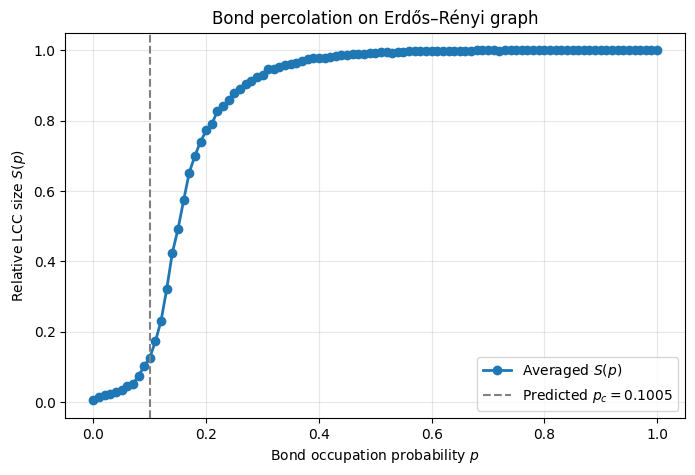

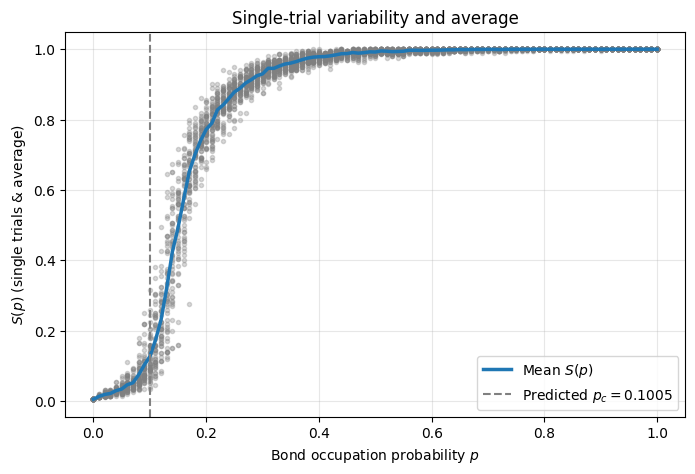

In [87]:

N = 200         
p0 = 0.05

G = nx.erdos_renyi_graph(N, p0)


mean_k0 = p0 * (N - 1)
p_c = 1 / mean_k0

print(f"Initial graph: N={N}, p0={p0}")
print(f"Initial mean degree <k0> = {mean_k0:.2f}")
print(f"Predicted percolation threshold p_c ≈ 1/<k0> = {p_c:.4f}")

ps = np.linspace(0, 1, 101)     
n_trials = 50                

S_avg = np.zeros(len(ps))       
S_single = np.zeros((len(ps), n_trials))  

for i, p in enumerate(ps):
    sizes = []
    for t in range(n_trials):
        H = bond_percolation(G, p)  
        if len(H) > 0:
            L = max(len(cc) for cc in nx.connected_components(H))
        else:
            L = 0
        sizes.append(L / N)
    S_avg[i] = np.mean(sizes)
    S_single[i, :] = sizes


plt.figure(figsize=(8, 5))
plt.plot(ps, S_avg, 'o-', color='C0', linewidth=2, label='Averaged $S(p)$')
plt.axvline(p_c, color='gray', linestyle='--', linewidth=1.5,
            label=f'Predicted $p_c = {p_c:.4f}$')
plt.xlabel('Bond occupation probability $p$')
plt.ylabel('Relative LCC size $S(p)$')
plt.title('Bond percolation on Erdős–Rényi graph')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(8, 5))
for t in range(n_trials):
    plt.plot(ps, S_single[:, t], 'o', color='gray', alpha=0.3, markersize=3)


plt.plot(ps, S_avg, '-', color='C0', linewidth=2.5, label='Mean $S(p)$')
plt.axvline(p_c, color='gray', linestyle='--', linewidth=1.5,
            label=f'Predicted $p_c = {p_c:.4f}$')
plt.xlabel('Bond occupation probability $p$')
plt.ylabel('$S(p)$ (single trials & average)')
plt.title('Single‑trial variability and average')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Thanks.
